In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import PercentFormatter
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import re
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import acorr_ljungbox

sns.set_style("whitegrid")

In [2]:
macro_path = './output/ccar_macro_data_quarterly.csv'
df_macro = pd.read_csv(macro_path)
df_macro['DATE'] = pd.to_datetime(df_macro['DATE'])
df_macro.set_index('DATE', inplace=True)
df_macro.index = df_macro.index.to_period('Q')
print(df_macro.describe())

       Unemployment_Rate      Real_GDP  BBB_Spread  VIX_Volatility_Index  \
count         104.000000    104.000000  104.000000            104.000000   
mean            5.640545  18273.150202    1.980944             19.834158   
std             1.936582   2847.680659    0.997186              7.394865   
min             3.533333  13878.147000    0.994030             10.307937   
25%             4.166667  16319.276250    1.321654             14.466469   
50%             5.016667  17576.126000    1.751620             17.872615   
75%             6.208333  20463.450500    2.280861             24.013756   
max            13.000000  24111.830000    7.030462             58.604687   

       10Y_Treasury_Yield  3M_Treasury_Rate  Prime_Rate  CPI_Inflation  \
count          104.000000        104.000000  104.000000     104.000000   
mean             3.322854          1.889647    5.102782     233.471003   
std              1.285874          1.933953    2.012014      41.567073   
min              0.

In [3]:
co_path = './output/Fed_CO.csv' 
dr_path = './output/Fed_DR.csv'

df_co = pd.read_csv(co_path)
df_dr = pd.read_csv(dr_path)

df_co['Quarter_dt'] = pd.to_datetime(df_co['Quarter_dt'])
df_co.set_index('Quarter_dt', inplace=True)
df_co.index = df_co.index.to_period('Q')

df_dr['Quarter_dt'] = pd.to_datetime(df_dr['Quarter_dt'])
df_dr.set_index('Quarter_dt', inplace=True)
df_dr.index = df_dr.index.to_period('Q')

df_lgd = df_co.join(df_dr, how='inner')
print(df_lgd.describe())

       Wholesale_Proxy_NCO  Retail_Proxy_NCO  Wholesale_Proxy_DR  \
count           103.000000        103.000000          103.000000   
mean              0.006801          0.044142            0.016971   
std               0.006228          0.018847            0.010495   
min               0.001000          0.015600            0.005800   
25%               0.002700          0.034400            0.010150   
50%               0.004300          0.038600            0.012500   
75%               0.008100          0.050800            0.021300   
max               0.026700          0.106400            0.045400   

       Retail_Proxy_DR  
count       103.000000  
mean          0.033783  
std           0.012476  
min           0.014400  
25%           0.023900  
50%           0.030300  
75%           0.043450  
max           0.068700  


In [4]:
# Calculate Wholesale LGD (CO / DR)
zero_dr_count = (df_lgd['Wholesale_Proxy_DR'] == 0).sum()
print(zero_dr_count)
df_lgd['Wholesale_LGD'] = df_lgd['Wholesale_Proxy_NCO'] / df_lgd['Wholesale_Proxy_DR']
nan_count = df_lgd['Wholesale_LGD'].isna().sum()
print(nan_count)
print(df_lgd['Wholesale_LGD'])

0
0
Quarter_dt
2000Q1    0.308901
2000Q2    0.336538
2000Q3    0.325688
2000Q4    0.413502
2001Q1    0.428571
            ...   
2024Q3    0.522936
2024Q4    0.416667
2025Q1    0.474576
2025Q2    0.491525
2025Q3    0.464000
Freq: Q-DEC, Name: Wholesale_LGD, Length: 103, dtype: float64


In [5]:
df_model = df_lgd[['Wholesale_LGD']].join(df_macro, how='inner')
print(df_model.describe())

       Wholesale_LGD  Unemployment_Rate      Real_GDP  BBB_Spread  \
count     103.000000         103.000000    103.000000  103.000000   
mean        0.359974           5.652104  18216.463990    1.990295   
std         0.130622           1.942443   2802.021705    0.997470   
min         0.090909           3.533333  13878.147000    0.994030   
25%         0.278556           4.166667  16312.271500    1.378204   
50%         0.344444           5.033333  17489.852000    1.760625   
75%         0.451976           6.216667  20368.257500    2.281876   
max         0.643229          13.000000  24026.834000    7.030462   

       VIX_Volatility_Index  10Y_Treasury_Yield  3M_Treasury_Rate  Prime_Rate  \
count            103.000000          103.000000        103.000000  103.000000   
mean              19.854439            3.315309          1.871780    5.084138   
std                7.428119            1.289846          1.934765    2.012805   
min               10.307937            0.650625       

In [6]:
candidate_macros = [
    # Levels (raw series)
    'Unemployment_Rate','Real_GDP','Nominal_GDP','Corporate_Profits','House_Price_Index',
    'Stock_Market_Index','CPI_Inflation','Real_Disposable_Income','Industrial_Production','Capacity_Utilization',

    # Credit conditions (levels)
    'BBB_Spread','HY_Spread','AAA_Spread','AA_Spread',

    # Financial stress (levels)
    'VIX_Volatility_Index','NFCI_Financial_Conditions','STLFSI_Financial_Stress',

    # Rates (levels)
    '10Y_Treasury_Yield','3M_Treasury_Rate','Prime_Rate',

    # Transforms
    'Real_GDP_Growth','Nominal_GDP_Growth','Corp_Profits_YoY','HPI_YoY','Stock_Market_Return',
    'CPI_YoY','RDI_YoY','RDI_Growth','INDPRO_YoY','INDPRO_Growth','TCU_Change',
    'Term_Spread_10Y_3M','10Y_Change','3M_Change','Prime_Change','BBB_Change','HY_Change',
]

lags_to_test = [1, 2, 3, 4]

available_macros = [m for m in candidate_macros if m in df_model.columns]
missing_macros = [m for m in candidate_macros if m not in df_model.columns]
print("Available macros:", len(available_macros))
print("Missing macros (ignored):", missing_macros)

lagged_cols = {}

# LGD lags
for lag in lags_to_test:
    lagged_cols[f"LGD_Lag{lag}"] = df_model["Wholesale_LGD"].shift(lag)

# Macro lags
for m in available_macros:
    for lag in lags_to_test:
        lagged_cols[f"{m}_Lag{lag}"] = df_model[m].shift(lag)

df_lags = pd.DataFrame(lagged_cols, index=df_model.index)

df_model = pd.concat([df_model, df_lags], axis=1)
df_model = df_model.dropna().copy() 

df_model.to_csv("./output/wholesale_lgd_model_candidates.csv")
print("Saved:", df_model.shape)

Available macros: 37
Missing macros (ignored): []
Saved: (99, 190)


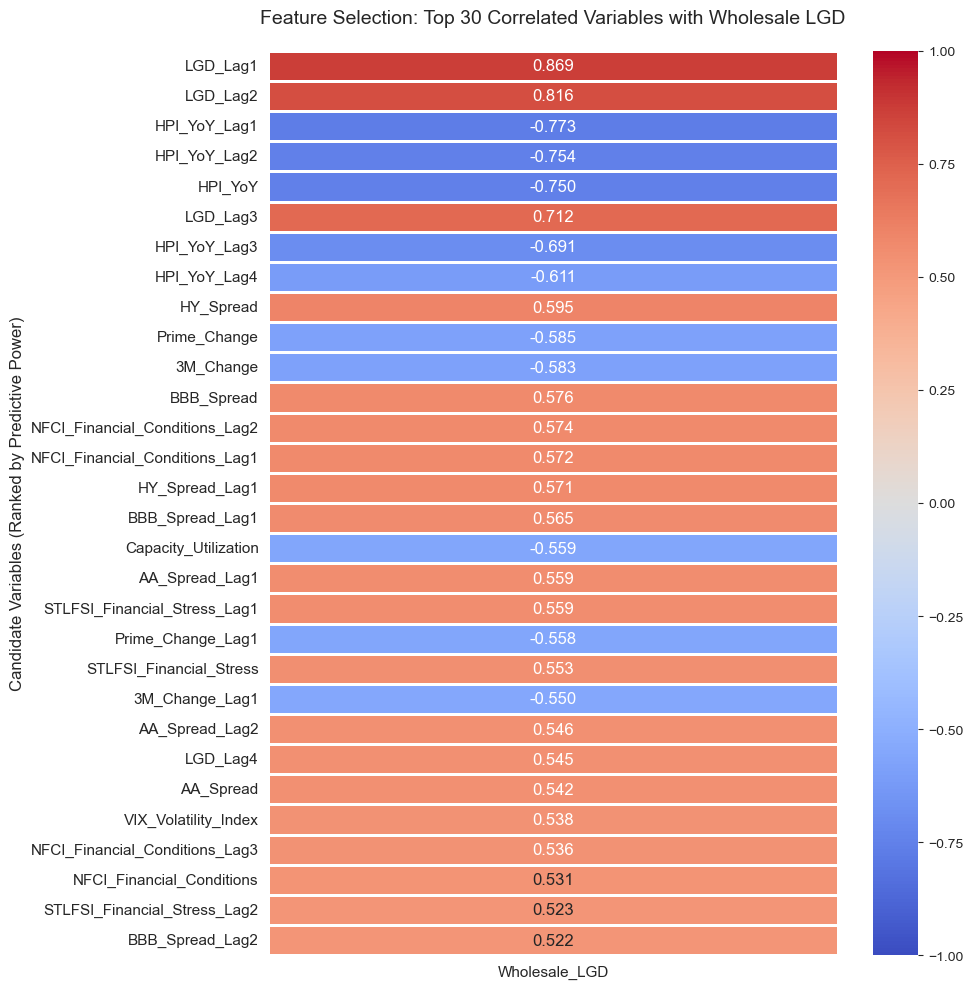

In [7]:
plt.figure(figsize=(10, 10))

target = 'Wholesale_LGD'

corr_with_lgd = df_model.corr()[[target]].drop(target)
corr_with_lgd['Absolute_Corr'] = corr_with_lgd[target].abs()
corr_with_lgd_sorted = corr_with_lgd.sort_values(by='Absolute_Corr', ascending=False)
corr_with_lgd_sorted.drop(columns=['Absolute_Corr'], inplace=True)

top_30_features = corr_with_lgd_sorted.head(30)

sns.heatmap(top_30_features, annot=True, annot_kws={"size": 12}, 
            cmap='coolwarm', fmt=".3f", linewidths=1, vmin=-1, vmax=1)

plt.title('Feature Selection: Top 30 Correlated Variables with Wholesale LGD', fontsize=14, pad=20)
plt.ylabel('Candidate Variables (Ranked by Predictive Power)', fontsize=12)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.savefig('./output/chart_lgd_wholesale_feature_selection.png', dpi=600, bbox_inches='tight')
plt.show()

In [8]:
top30_names = corr_with_lgd_sorted.head(30).index.tolist()

def base_name(x):
    return re.sub(r"_Lag\d+$", "", x)

shortlist = []
seen = set()
for v in top30_names:
    b = base_name(v)
    if b not in seen:
        shortlist.append(v)
        seen.add(b)

print("Top30:", top30_names)
print("Shortlist (dedup by base):", shortlist)

Top30: ['LGD_Lag1', 'LGD_Lag2', 'HPI_YoY_Lag1', 'HPI_YoY_Lag2', 'HPI_YoY', 'LGD_Lag3', 'HPI_YoY_Lag3', 'HPI_YoY_Lag4', 'HY_Spread', 'Prime_Change', '3M_Change', 'BBB_Spread', 'NFCI_Financial_Conditions_Lag2', 'NFCI_Financial_Conditions_Lag1', 'HY_Spread_Lag1', 'BBB_Spread_Lag1', 'Capacity_Utilization', 'AA_Spread_Lag1', 'STLFSI_Financial_Stress_Lag1', 'Prime_Change_Lag1', 'STLFSI_Financial_Stress', '3M_Change_Lag1', 'AA_Spread_Lag2', 'LGD_Lag4', 'AA_Spread', 'VIX_Volatility_Index', 'NFCI_Financial_Conditions_Lag3', 'NFCI_Financial_Conditions', 'STLFSI_Financial_Stress_Lag2', 'BBB_Spread_Lag2']
Shortlist (dedup by base): ['LGD_Lag1', 'HPI_YoY_Lag1', 'HY_Spread', 'Prime_Change', '3M_Change', 'BBB_Spread', 'NFCI_Financial_Conditions_Lag2', 'Capacity_Utilization', 'AA_Spread_Lag1', 'STLFSI_Financial_Stress_Lag1', 'VIX_Volatility_Index']


In [9]:
def drop_high_corr_features(df, cols, threshold=0.95, prefer_keep=None, verbose=False):
    """
    Drop one feature from any pair with |corr| > threshold.
    prefer_keep: set/list of column names you prefer to keep if conflict.
    """
    prefer_keep = set(prefer_keep or [])
    X = df[cols].dropna()
    corr = X.corr().abs()

    to_drop = set()
    cols_order = list(corr.columns)

    for i in range(len(cols_order)):
        for j in range(i+1, len(cols_order)):
            a, b = cols_order[i], cols_order[j]
            if corr.loc[a, b] > threshold:

                if a in prefer_keep and b not in prefer_keep:
                    drop = b
                elif b in prefer_keep and a not in prefer_keep:
                    drop = a
                else:
                    drop = b

                to_drop.add(drop)

                if verbose:
                    print(f"High corr |{a} vs {b}| = {corr.loc[a,b]:.3f} -> drop {drop}")

    kept = [c for c in cols if c not in to_drop]
    return kept, sorted(to_drop), corr

# Prefer-keep rules(family-based): prefer by base name (more robust)
prefer_keep_base = {
    "3M_Change": True,      # prefer keeping 3M_Change over Prime_Change: policy rate proxy
    "BBB_Spread": True,     # prefer BBB over AA/HY if extreme corr occurs: corporate credit proxy
}

# Convert base preferences to exact names present in shortlist
prefer_keep = set()
for col in shortlist:
    base = base_name(col)
    if prefer_keep_base.get(base, False):  # only keep if explicitly marked True
        prefer_keep.add(col)

kept, dropped, corr_abs = drop_high_corr_features(
    df_model,
    shortlist,
    threshold=0.95,
    prefer_keep=prefer_keep,
    verbose=True
)

print("\nDropped due to extreme correlation:", dropped)
print("Kept:", kept)

High corr |HY_Spread vs BBB_Spread| = 0.962 -> drop HY_Spread

Dropped due to extreme correlation: ['HY_Spread']
Kept: ['LGD_Lag1', 'HPI_YoY_Lag1', 'Prime_Change', '3M_Change', 'BBB_Spread', 'NFCI_Financial_Conditions_Lag2', 'Capacity_Utilization', 'AA_Spread_Lag1', 'STLFSI_Financial_Stress_Lag1', 'VIX_Volatility_Index']


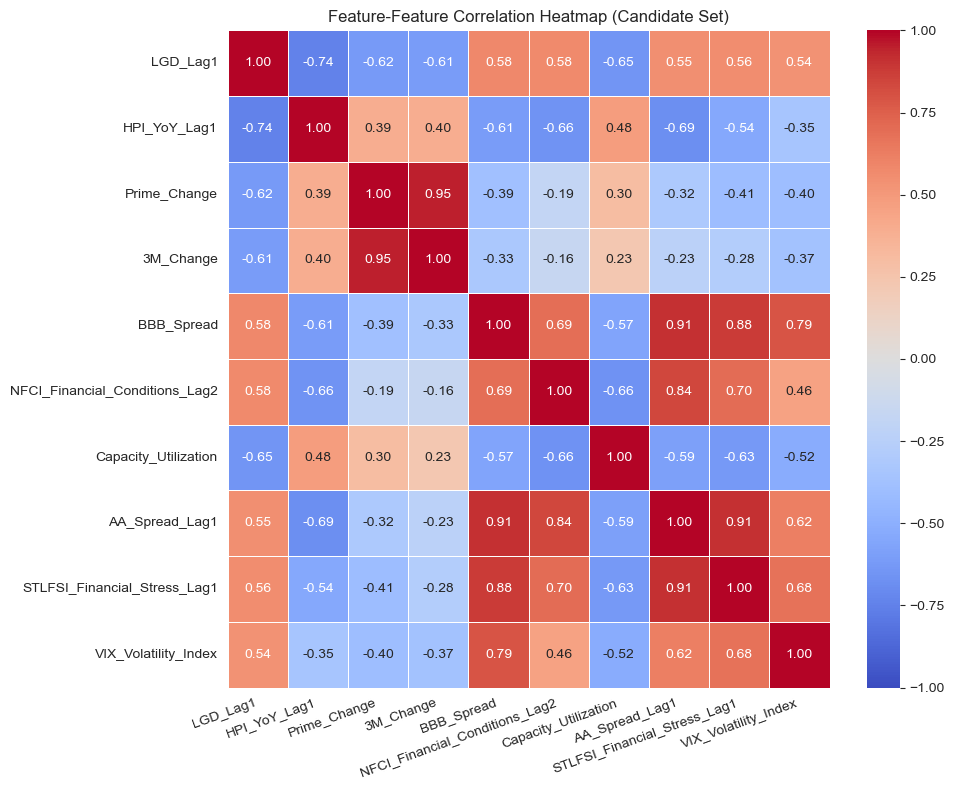

In [10]:
# Build Feature–Feature Corr Heatmap to avoid multicollinearity
df_sub = df_model[kept].dropna().copy()

corr = df_sub.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Feature-Feature Correlation Heatmap (Candidate Set)")
plt.xticks(rotation=20, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('./output/chart_lgd_wholesale_feature_candidate_correlation_heatmap.png', dpi=600, bbox_inches='tight')
plt.show()

In [11]:
# Build VIF (Variance Inflation Factor) table to see collinearity
# VIF = 1: almost no collinearity 
# VIF around 5: begins to raise red flags 
# VIF > 10: severe collinearity (coefficients are unstable, t-values/p-values are distorted, and signs are prone to being confused)
X = df_sub.copy()
X = sm.add_constant(X)

vif_table = pd.DataFrame({
    "Variable": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})

vif_table = vif_table[vif_table["Variable"] != "const"].sort_values("VIF", ascending=False)
print(vif_table)

                          Variable        VIF
8                   AA_Spread_Lag1  28.502022
3                     Prime_Change  15.336069
4                        3M_Change  14.673677
5                       BBB_Spread  14.084555
9     STLFSI_Financial_Stress_Lag1  10.601675
6   NFCI_Financial_Conditions_Lag2   6.405518
1                         LGD_Lag1   5.253612
2                     HPI_YoY_Lag1   4.505676
10            VIX_Volatility_Index   3.877816
7             Capacity_Utilization   2.751524


In [12]:
# Build the specification step-by-step, adding one candidate at a time and selecting the final model based on incremental fit (Adj-R2/AIC) and economic sign validity.
target = "Wholesale_LGD"

# Candidate set (after collinearity thinking)
CORE = ["LGD_Lag1", "HPI_YoY_Lag1"]

# Rate proxies
RATE_3M  = "3M_Change"
RATE_PRIME = "Prime_Change"

# Credit / stress proxies
CREDIT_BBB   = "BBB_Spread"
CREDIT_AA    = "AA_Spread_Lag1"  # usually very collinear with BBB
STRESS_NFCI  = "NFCI_Financial_Conditions_Lag2"
STRESS_STLFSI = "STLFSI_Financial_Stress_Lag1"
STRESS_VIX   = "VIX_Volatility_Index"


# Real activity
REAL_CAP = "Capacity_Utilization"

# Expected sign map (economic logic)
expected_sign = {
    "LGD_Lag1": +1,
    "HPI_YoY_Lag1": -1,

    # rates: tightening often worsens credit -> LGD up (negative)
    "3M_Change": -1,
    "Prime_Change": -1,

    # spreads/stress: stress up -> LGD up (positive)
    "BBB_Spread": +1,
    "AA_Spread_Lag1": +1,
    "NFCI_Financial_Conditions_Lag2": +1,
    "STLFSI_Financial_Stress_Lag1": +1,
    "VIX_Volatility_Index": +1,

    # capacity utilization: strong economy -> better recoveries -> LGD down (negative)
    "Capacity_Utilization": -1,
}

# Model specs
model_specs = {
    # Core build
    "M0: LGD_Lag1": ["LGD_Lag1"],
    "M1: + HPI_YoY_Lag1": CORE,

    # Rate channel showdown (pick one)
    "M2a: + 3M_Change (on top of Core)": CORE + [RATE_3M],
    "M2b: + Prime_Change (on top of Core)": CORE + [RATE_PRIME],

    # Stress/credit proxy showdown (on top of Core + 3M_Change baseline)
    "M3a: + BBB_Spread (on top of M2a)": CORE + [RATE_3M, CREDIT_BBB],
    "M3b: + NFCI_Lag2 (on top of M2a)": CORE + [RATE_3M, STRESS_NFCI],
    "M3c: + STLFSI_Lag1 (on top of M2a)": CORE + [RATE_3M, STRESS_STLFSI],
    "M3d: + VIX (on top of M2a)": CORE + [RATE_3M, STRESS_VIX],
    "M3e: + AA_Spread_Lag1 (on top of M2a) [optional]": CORE + [RATE_3M, CREDIT_AA],

    # Real economy add-on (on top of each stress proxy)
    "M4a: + Capacity (on top of M3a)": CORE + [RATE_3M, CREDIT_BBB, REAL_CAP],
    "M4b: + Capacity (on top of M3b)": CORE + [RATE_3M, STRESS_NFCI, REAL_CAP],
    "M4c: + Capacity (on top of M3c)": CORE + [RATE_3M, STRESS_STLFSI, REAL_CAP],
    "M4d: + Capacity (on top of M3d)": CORE + [RATE_3M, STRESS_VIX, REAL_CAP],

    # Limited combinations (avoid stacking highly correlated stress proxies too much)
    "M5a: + BBB + VIX (on top of M2a)": CORE + [RATE_3M, CREDIT_BBB, STRESS_VIX],
    "M5b: + NFCI + VIX (on top of M2a)": CORE + [RATE_3M, STRESS_NFCI, STRESS_VIX],
}

ordered_models = list(model_specs.keys())

# sign check table
def sign_check_table(res, expected_sign):
    coef_table = pd.DataFrame({
        "coef": res.params,
        "t": res.tvalues,
        "p": res.pvalues
    })

    def flag(v):
        if v not in expected_sign:
            return ""
        exp = expected_sign[v]
        act = 1 if coef_table.loc[v, "coef"] > 0 else -1
        return "OK" if act == exp else "WRONG"

    coef_table["sign_check"] = ""
    for v in coef_table.index:
        if v in expected_sign:
            coef_table.loc[v, "sign_check"] = flag(v)

    return coef_table

# Build common-sample dataframe (use all variables that appear in any model)

all_X = sorted(set([x for xs in model_specs.values() for x in xs]))
df_common = df_model[[target] + all_X].dropna().copy()

def fit_model(df, y, X_cols):
    y_vec = df[y]
    X = sm.add_constant(df[X_cols])
    return sm.OLS(y_vec, X).fit()

rows = []
prev_res = None

for name in ordered_models:
    X_cols = model_specs[name]
    res = fit_model(df_common, target, X_cols)

    print("\n" + "="*95)
    print(name, "| X =", X_cols)
    print(sign_check_table(res, expected_sign).round(4))
    print(f"R2={res.rsquared:.4f} | Adj_R2={res.rsquared_adj:.4f} | AIC={res.aic:.3f} | BIC={res.bic:.3f} | N={int(res.nobs)}")
    print("="*95)

    row = {
        "Model": name,
        "N": int(res.nobs),
        "R2": res.rsquared,
        "Adj_R2": res.rsquared_adj,
        "AIC": res.aic,
        "BIC": res.bic,
    }

    if prev_res is None:
        row["ΔAdj_R2_vs_prev"] = np.nan
        row["ΔAIC_vs_prev"] = np.nan
    else:
        row["ΔAdj_R2_vs_prev"] = res.rsquared_adj - prev_res.rsquared_adj
        row["ΔAIC_vs_prev"] = res.aic - prev_res.aic

    rows.append(row)
    prev_res = res

summary = pd.DataFrame(rows)
print("\n\nMODEL COMPARISON (narrative order, common sample):")
print(summary.round(6))


M0: LGD_Lag1 | X = ['LGD_Lag1']
            coef        t      p sign_check
const     0.0469   2.4288  0.017           
LGD_Lag1  0.8713  17.3203  0.000         OK
R2=0.7557 | Adj_R2=0.7531 | AIC=-255.037 | BIC=-249.847 | N=99

M1: + HPI_YoY_Lag1 | X = ['LGD_Lag1', 'HPI_YoY_Lag1']
                coef       t       p sign_check
const         0.1498  4.7906  0.0000           
LGD_Lag1      0.6614  9.4322  0.0000         OK
HPI_YoY_Lag1 -0.5458 -4.0196  0.0001         OK
R2=0.7909 | Adj_R2=0.7865 | AIC=-268.437 | BIC=-260.651 | N=99

M2a: + 3M_Change (on top of Core) | X = ['LGD_Lag1', 'HPI_YoY_Lag1', '3M_Change']
                coef       t       p sign_check
const         0.1788  5.1652  0.0000           
LGD_Lag1      0.5832  7.1932  0.0000         OK
HPI_YoY_Lag1 -0.5750 -4.2585  0.0000         OK
3M_Change    -0.0327 -1.8534  0.0669         OK
R2=0.7982 | Adj_R2=0.7918 | AIC=-269.953 | BIC=-259.573 | N=99

M2b: + Prime_Change (on top of Core) | X = ['LGD_Lag1', 'HPI_YoY_Lag1', 'Pr

In [13]:
final_cols = ["LGD_Lag1", "HPI_YoY_Lag1", "3M_Change", "VIX_Volatility_Index"]
df_tmp = df_model[[target] + final_cols].dropna().copy()
y = df_tmp[target]
X = sm.add_constant(df_tmp[final_cols])

res = sm.OLS(y, X).fit()

print("\n" + "="*90)
print("FINAL MODEL (OLS) summary (standard SE):")
print(res.summary())
print("="*90)

# 1) Residual autocorrelation checks
dw = durbin_watson(res.resid)
print(f"\nDurbin-Watson: {dw:.3f}  (≈2 means no strong AR(1) autocorrelation)")

# Ljung-Box for multiple lags (quarterly: try 4 and 8)
lb = acorr_ljungbox(res.resid, lags=[4, 8], return_df=True)
print("\nLjung-Box test (residual autocorrelation):")
print(lb)

# 2) HAC (Newey-West) robust standard errors
# Quarterly data: maxlags=4 is a common default (one year)
res_hac = res.get_robustcov_results(cov_type="HAC", maxlags=4)

hac_table = pd.DataFrame({
    "coef": res_hac.params,
    "t(HAC)": res_hac.tvalues,
    "p(HAC)": res_hac.pvalues,
})
print("\n" + "="*90)
print("FINAL MODEL with Newey-West (HAC, maxlags=4) robust inference:")
print(hac_table.round(6))
print("="*90)


FINAL MODEL (OLS) summary (standard SE):
                            OLS Regression Results                            
Dep. Variable:          Wholesale_LGD   R-squared:                       0.807
Model:                            OLS   Adj. R-squared:                  0.799
Method:                 Least Squares   F-statistic:                     98.56
Date:                Wed, 25 Mar 2026   Prob (F-statistic):           9.15e-33
Time:                        14:13:57   Log-Likelihood:                 141.32
No. Observations:                  99   AIC:                            -272.6
Df Residuals:                      94   BIC:                            -259.7
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------

In [14]:
# Compute VIF
df_vif = df_model[final_cols].dropna().copy()
X = sm.add_constant(df_vif)

vif_table = pd.DataFrame({
    "Variable": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})

print("VIF (Variance Inflation Factor) Check")
print(vif_table.round(3))

VIF (Variance Inflation Factor) Check
               Variable     VIF
0                 const  33.589
1              LGD_Lag1   3.550
2          HPI_YoY_Lag1   2.292
3             3M_Change   1.630
4  VIX_Volatility_Index   1.419


In [15]:
# Forecast
# scenario data
scenario = pd.read_csv("./raw_data/Severely Adverse Scenario Data.csv").copy()

scenario["Date"] = scenario["Date"].astype(str).str.replace(" ", "", regex=False)
scenario["Date"] = pd.PeriodIndex(scenario["Date"], freq="Q")

# Rename columns to match model inputs
scenario = scenario.rename(columns={
    "House Price Index (Level)": "House_Price_Index",
    "3-month Treasury rate": "ThreeM_Rate",
    "Market Volatility Index (Level)": "VIX_Volatility_Index"
})
print(scenario.head())


     Date  Real GDP growth  Nominal GDP growth  Real disposable income growth  \
0  2000Q1              1.5                 4.2                            7.2   
1  2000Q2              7.5                10.2                            4.8   
2  2000Q3              0.4                 2.8                            5.4   
3  2000Q4              2.4                 4.6                            2.7   
4  2001Q1             -1.3                 1.3                            3.2   

   Nominal disposable income growth  Unemployment rate  CPI inflation rate  \
0                              10.7                4.0                 4.0   
1                               6.8                3.9                 3.2   
2                               8.1                4.0                 3.7   
3                               5.1                3.9                 2.9   
4                               6.3                4.2                 3.9   

   ThreeM_Rate  5-year Treasury yield  10-ye

In [31]:
# Build model features exactly as in training
scenario["HPI_YoY"] = scenario["House_Price_Index"].pct_change(4)
scenario["HPI_YoY_Lag1"] = scenario["HPI_YoY"].shift(1)
scenario["3M_Change"] = scenario["ThreeM_Rate"].diff(1)

# Set last ACTUAL historical LGD and forecast 2025Q4 using actual 2025Q3 LGD
last_actual_q3_lgd = df_model.loc[pd.Period("2025Q3", freq="Q"), "Wholesale_LGD"]
q_bridge = pd.Period("2025Q4", freq="Q")

hpi_lag1_q4 = scenario.loc[scenario["Date"] == q_bridge, "HPI_YoY_Lag1"].iloc[0]
d3m_q4 = scenario.loc[scenario["Date"] == q_bridge, "3M_Change"].iloc[0]
vix_q4 = scenario.loc[scenario["Date"] == q_bridge, "VIX_Volatility_Index"].iloc[0]

b0 = res.params["const"]
b1 = res.params["LGD_Lag1"]
b2 = res.params["HPI_YoY_Lag1"]
b3 = res.params["3M_Change"]
b4 = res.params["VIX_Volatility_Index"]

lgd_2025q4_hat = (
    b0
    + b1 * last_actual_q3_lgd
    + b2 * hpi_lag1_q4
    + b3 * d3m_q4
    + b4 * vix_q4
)
print({
    "const": b0,
    "LGD_Lag1": b1,
    "HPI_YoY_Lag1": b2,
    "3M_Change": b3,
    "VIX_Volatility_Index": b4
})
print("Predicted 2025Q4 LGD (bridge quarter):", round(lgd_2025q4_hat, 6))

{'const': 0.16379836520473418, 'LGD_Lag1': 0.5168448601784503, 'HPI_YoY_Lag1': -0.5975807844698824, '3M_Change': -0.03068314631946382, 'VIX_Volatility_Index': 0.0020311565948262153}
Predicted 2025Q4 LGD (bridge quarter): 0.462204


In [32]:
# Forecast 2026Q1 to 2029Q1 recursively
proj = scenario.loc[
    (scenario["Date"] >= pd.Period("2026Q1", freq="Q")) &
    (scenario["Date"] <= pd.Period("2029Q1", freq="Q")),
    ["Date", "HPI_YoY_Lag1", "3M_Change", "VIX_Volatility_Index"]
].copy()

preds = []
prev_lgd = lgd_2025q4_hat

for _, row in proj.iterrows():
    q = row["Date"]
    hpi = row["HPI_YoY_Lag1"]
    d3m = row["3M_Change"]
    vix = row["VIX_Volatility_Index"]

    lgd_hat = (
        b0
        + b1 * prev_lgd
        + b2 * hpi
        + b3 * d3m
        + b4 * vix
    )

    preds.append({
        "Quarter": q,
        "LGD_Lag1_used": prev_lgd,
        "HPI_YoY_Lag1": hpi,
        "3M_Change": d3m,
        "VIX": vix,
        "Pred_Wholesale_LGD": lgd_hat
    })

    prev_lgd = lgd_hat

forecast_lgd = pd.DataFrame(preds)

print("\nForecast LGD path:")
print(forecast_lgd.round(6))


Forecast LGD path:
   Quarter  LGD_Lag1_used  HPI_YoY_Lag1  3M_Change   VIX  Pred_Wholesale_LGD
0   2026Q1       0.462204      0.004348       -1.2  59.7            0.558168
1   2026Q2       0.558168     -0.060174       -2.4  72.0            0.708126
2   2026Q3       0.708126     -0.120497        0.0  70.9            0.745805
3   2026Q4       0.745805     -0.154227        0.0  66.6            0.776702
4   2027Q1       0.776702     -0.186456        0.0  62.3            0.803197
5   2027Q2       0.803197     -0.163036        0.0  58.1            0.794364
6   2027Q3       0.794364     -0.137006        0.0  53.8            0.765510
7   2027Q4       0.765510     -0.136946        0.0  49.5            0.741827
8   2028Q1       0.741827     -0.136070        0.0  45.3            0.720532
9   2028Q2       0.720532     -0.089905        0.0  41.0            0.673205
10  2028Q3       0.673205     -0.040507        0.0  36.7            0.610491
11  2028Q4       0.610491      0.010607        0.0  32.5

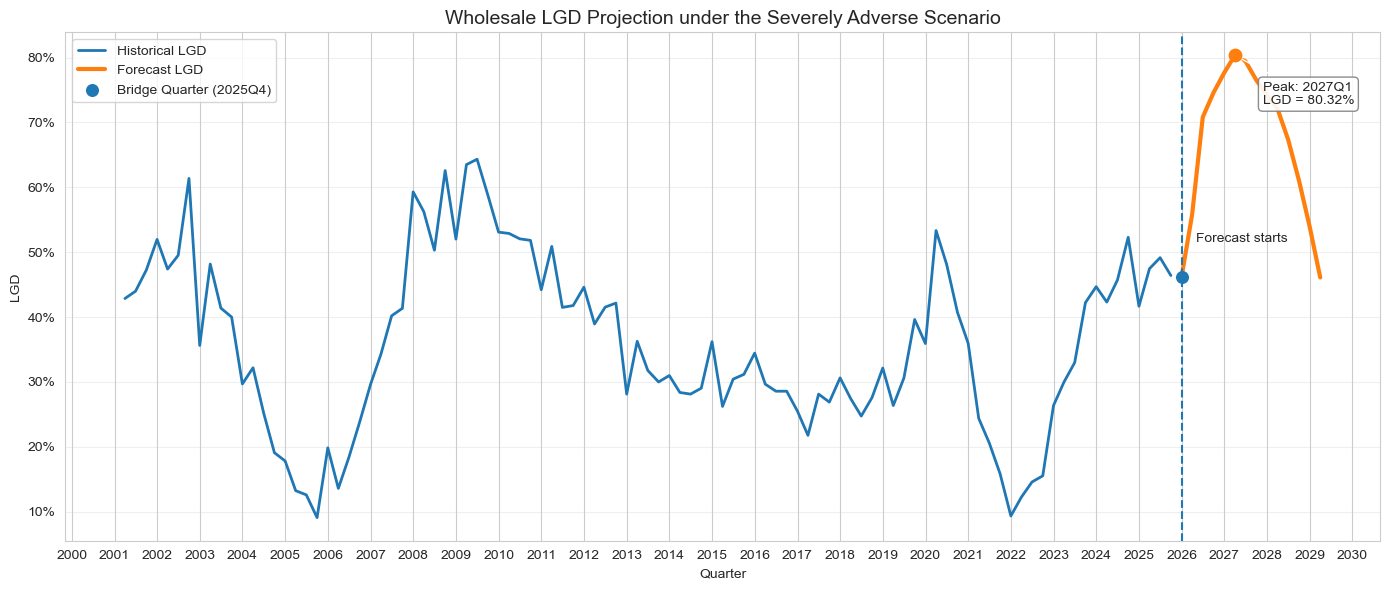

In [33]:
# Historical + Forecast LGD plot

hist = df_model[["Wholesale_LGD"]].copy().reset_index()
hist = hist.rename(columns={hist.columns[0]: "Quarter"})
hist["Quarter"] = hist["Quarter"].astype(str)

# convert quarter string to quarter-end date
hist["Date"] = hist["Quarter"].str.replace("Q1", "-03-31") \
                             .str.replace("Q2", "-06-30") \
                             .str.replace("Q3", "-09-30") \
                             .str.replace("Q4", "-12-31")
hist["Date"] = pd.to_datetime(hist["Date"])

# Bridge quarter (2025Q4)
bridge_df = pd.DataFrame({
    "Quarter": ["2025Q4"],
    "Wholesale_LGD": [lgd_2025q4_hat],
    "Date": [pd.Timestamp("2025-12-31")]
})

# Forecast path
fcst_plot = forecast_lgd.copy()
fcst_plot["Quarter"] = fcst_plot["Quarter"].astype(str)
fcst_plot["Date"] = fcst_plot["Quarter"].str.replace("Q1", "-03-31") \
                                      .str.replace("Q2", "-06-30") \
                                      .str.replace("Q3", "-09-30") \
                                      .str.replace("Q4", "-12-31")
fcst_plot["Date"] = pd.to_datetime(fcst_plot["Date"])
fcst_plot = fcst_plot.rename(columns={"Pred_Wholesale_LGD": "Wholesale_LGD"})

# Split actual vs forecast
actual_cutoff = pd.Timestamp("2025-09-30")
forecast_start = pd.Timestamp("2025-12-31")

actual_part = hist[hist["Date"] <= actual_cutoff].copy()
forecast_part = pd.concat([bridge_df, fcst_plot[["Date", "Quarter", "Wholesale_LGD"]]], ignore_index=True)

# peak forecast point
peak_idx = forecast_part["Wholesale_LGD"].idxmax()
peak_row = forecast_part.loc[peak_idx]

# Plot
plt.figure(figsize=(14, 6))

# historical actual
plt.plot(
    actual_part["Date"],
    actual_part["Wholesale_LGD"],
    label="Historical LGD",
    linewidth=2
)

# forecast path
plt.plot(
    forecast_part["Date"],
    forecast_part["Wholesale_LGD"],
    label="Forecast LGD",
    linewidth=3
)

# bridge point
plt.scatter(
    bridge_df["Date"],
    bridge_df["Wholesale_LGD"],
    s=70,
    zorder=5,
    label="Bridge Quarter (2025Q4)"
)

# forecast start line
plt.axvline(
    x=forecast_start,
    linestyle="--",
    linewidth=1.5
)

# annotate peak
plt.scatter(
    peak_row["Date"],
    peak_row["Wholesale_LGD"],
    s=80,
    zorder=6
)

plt.annotate(
    f"Peak: {peak_row['Quarter']}\nLGD = {peak_row['Wholesale_LGD']:.2%}",
    xy=(peak_row["Date"], peak_row["Wholesale_LGD"]),
    xytext=(20, -35),
    textcoords="offset points",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.9),
    arrowprops=dict(arrowstyle="->", lw=1)
)

# annotate forecast start
plt.annotate(
    "Forecast starts",
    xy=(forecast_start, bridge_df["Wholesale_LGD"].iloc[0]),
    xytext=(10, 25),
    textcoords="offset points",
    fontsize=10
)

# formatting
plt.title("Wholesale LGD Projection under the Severely Adverse Scenario", fontsize=14)
plt.xlabel("Quarter")
plt.ylabel("LGD")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.yaxis.set_major_formatter(PercentFormatter(1.0))

plt.legend(frameon=True)
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [34]:
target = "Wholesale_LGD"

# Final model
final_cols = ["LGD_Lag1", "HPI_YoY_Lag1", "3M_Change", "VIX_Volatility_Index"]
df_final = df_model[[target] + final_cols].dropna().copy()
res_final = sm.OLS(df_final[target], sm.add_constant(df_final[final_cols])).fit()

# Conservative model
cons_cols = ["LGD_Lag1", "HPI_YoY_Lag1", "3M_Change"]
df_cons = df_model[[target] + cons_cols].dropna().copy()
res_cons = sm.OLS(df_cons[target], sm.add_constant(df_cons[cons_cols])).fit()

# Minimal core model
core_cols = ["LGD_Lag1", "HPI_YoY_Lag1"]
df_core = df_model[[target] + core_cols].dropna().copy()
res_core = sm.OLS(df_core[target], sm.add_constant(df_core[core_cols])).fit()

print("Final model coefficients:")
print(res_final.params)
print("\nConservative model coefficients:")
print(res_cons.params)
print("\nCore model coefficients:")
print(res_core.params)

Final model coefficients:
const                   0.163798
LGD_Lag1                0.516845
HPI_YoY_Lag1           -0.597581
3M_Change              -0.030683
VIX_Volatility_Index    0.002031
dtype: float64

Conservative model coefficients:
const           0.178785
LGD_Lag1        0.583188
HPI_YoY_Lag1   -0.575004
3M_Change      -0.032710
dtype: float64

Core model coefficients:
const           0.149816
LGD_Lag1        0.661350
HPI_YoY_Lag1   -0.545837
dtype: float64


In [35]:
# Bridge quarter: forecast 2025Q4 from actual 2025Q3
# Final
lgd_2025q4_final = (
    res_final.params["const"]
    + res_final.params["LGD_Lag1"] * last_actual_q3_lgd
    + res_final.params["HPI_YoY_Lag1"] * hpi_lag1_q4
    + res_final.params["3M_Change"] * d3m_q4
    + res_final.params["VIX_Volatility_Index"] * vix_q4
)

# Conservative
lgd_2025q4_cons = (
    res_cons.params["const"]
    + res_cons.params["LGD_Lag1"] * last_actual_q3_lgd
    + res_cons.params["HPI_YoY_Lag1"] * hpi_lag1_q4
    + res_cons.params["3M_Change"] * d3m_q4
)

# Core
lgd_2025q4_core = (
    res_core.params["const"]
    + res_core.params["LGD_Lag1"] * last_actual_q3_lgd
    + res_core.params["HPI_YoY_Lag1"] * hpi_lag1_q4
)

print("\nBridge forecasts for 2025Q4:")
print("Final model:", round(lgd_2025q4_final, 6))
print("Conservative model:", round(lgd_2025q4_cons, 6))
print("Core model:", round(lgd_2025q4_core, 6))


Bridge forecasts for 2025Q4:
Final model: 0.462204
Conservative model: 0.455438
Core model: 0.450009


In [36]:
proj = scenario.loc[
    (scenario["Date"] >= pd.Period("2026Q1", freq="Q")) &
    (scenario["Date"] <= pd.Period("2029Q1", freq="Q")),
    ["Date", "HPI_YoY_Lag1", "3M_Change", "VIX_Volatility_Index"]
].copy()

# Recursive forecast function
def recursive_forecast(model_name, res, proj_df, start_lgd, use_3m=True, use_vix=True):
    preds = []
    prev_lgd = start_lgd

    for _, row in proj_df.iterrows():
        q = row["Date"]
        hpi = row["HPI_YoY_Lag1"]
        d3m = row["3M_Change"]
        vix = row["VIX_Volatility_Index"]

        lgd_hat = (
            res.params["const"]
            + res.params["LGD_Lag1"] * prev_lgd
            + res.params["HPI_YoY_Lag1"] * hpi
        )

        if use_3m:
            lgd_hat += res.params["3M_Change"] * d3m
        if use_vix:
            lgd_hat += res.params["VIX_Volatility_Index"] * vix

        preds.append({
            "Quarter": q,
            "Model": model_name,
            "LGD_Lag1_used": prev_lgd,
            "HPI_YoY_Lag1": hpi,
            "3M_Change": d3m,
            "VIX": vix,
            "Pred_Wholesale_LGD": lgd_hat
        })

        prev_lgd = lgd_hat

    return pd.DataFrame(preds)

# Generate three forecast paths
forecast_final = recursive_forecast(
    model_name="Final: LGD_Lag1 + HPI + 3M_Change + VIX",
    res=res_final,
    proj_df=proj,
    start_lgd=lgd_2025q4_final,
    use_3m=True,
    use_vix=True
)

forecast_cons = recursive_forecast(
    model_name="Conservative: LGD_Lag1 + HPI + 3M_Change",
    res=res_cons,
    proj_df=proj,
    start_lgd=lgd_2025q4_cons,
    use_3m=True,
    use_vix=False
)

forecast_core = recursive_forecast(
    model_name="Core: LGD_Lag1 + HPI",
    res=res_core,
    proj_df=proj,
    start_lgd=lgd_2025q4_core,
    use_3m=False,
    use_vix=False
)

# Merge for comparison table
compare = forecast_final[["Quarter", "Pred_Wholesale_LGD"]].rename(
    columns={"Pred_Wholesale_LGD": "Final_Model"}
).merge(
    forecast_cons[["Quarter", "Pred_Wholesale_LGD"]].rename(
        columns={"Pred_Wholesale_LGD": "Conservative_Model"}
    ),
    on="Quarter",
    how="inner"
).merge(
    forecast_core[["Quarter", "Pred_Wholesale_LGD"]].rename(
        columns={"Pred_Wholesale_LGD": "Core_Model"}
    ),
    on="Quarter",
    how="inner"
)

print("\nForecast comparison table:")
print(compare)


Forecast comparison table:
   Quarter  Final_Model  Conservative_Model  Core_Model
0   2026Q1     0.558168            0.481142    0.445056
1   2026Q2     0.708126            0.572485    0.476999
2   2026Q3     0.745805            0.581937    0.531051
3   2026Q4     0.776702            0.606845    0.585209
4   2027Q1     0.803197            0.639903    0.638619
5   2027Q2     0.794364            0.645715    0.661158
6   2027Q3     0.765510            0.634137    0.661856
7   2027Q4     0.741827            0.627350    0.662284
8   2028Q1     0.720532            0.622889    0.662090
9   2028Q2     0.673205            0.593742    0.636763
10  2028Q3     0.610491            0.548340    0.593049
11  2028Q4     0.539002            0.492471    0.536240
12  2029Q1     0.461010            0.428801    0.469158


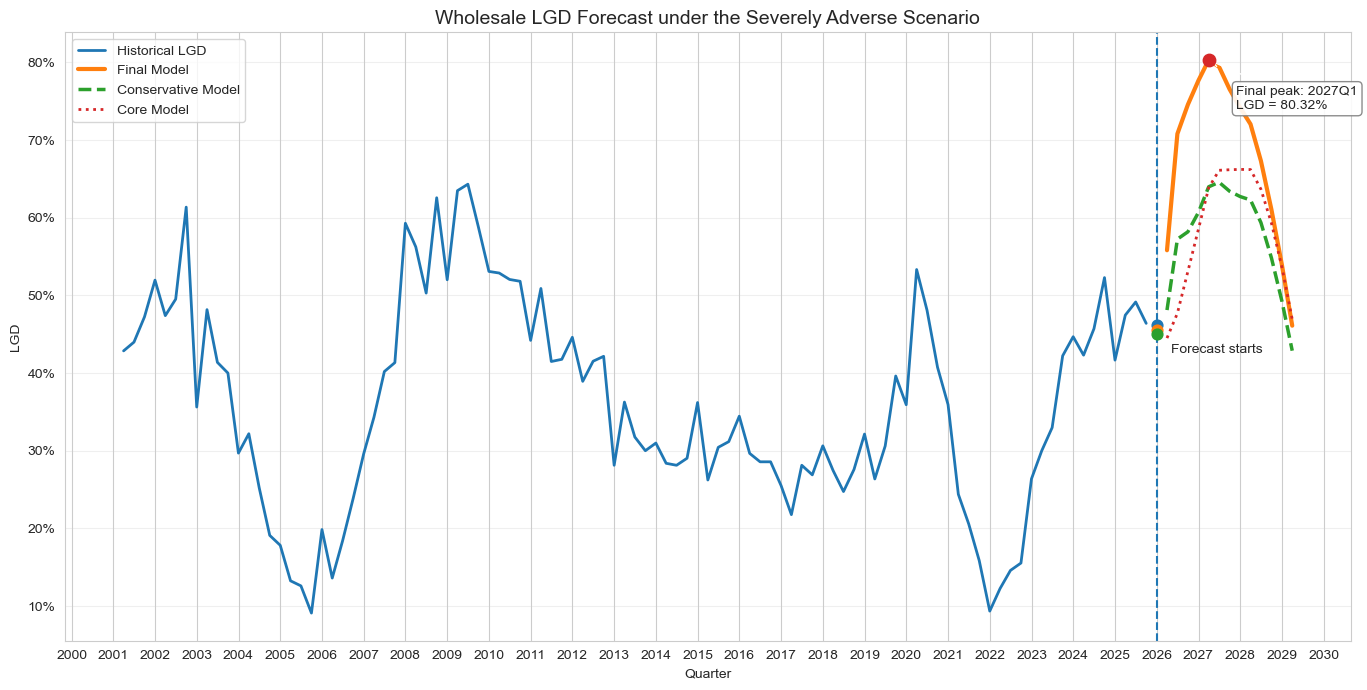

In [39]:
hist = df_model[["Wholesale_LGD"]].copy().reset_index()
hist = hist.rename(columns={hist.columns[0]: "Quarter"})
hist["Quarter"] = hist["Quarter"].astype(str)
hist["Date"] = hist["Quarter"].str.replace("Q1", "-03-31") \
                             .str.replace("Q2", "-06-30") \
                             .str.replace("Q3", "-09-30") \
                             .str.replace("Q4", "-12-31")
hist["Date"] = pd.to_datetime(hist["Date"])

actual_cutoff = pd.Timestamp("2025-09-30")
forecast_start = pd.Timestamp("2025-12-31")

# bridge points
bridge_points = pd.DataFrame({
    "Date": [pd.Timestamp("2025-12-31")] * 3,
    "Quarter": ["2025Q4"] * 3,
    "Model": ["Final", "Conservative", "Core"],
    "Wholesale_LGD": [lgd_2025q4_final, lgd_2025q4_cons, lgd_2025q4_core]
})

# convert forecasts to plot-ready format
def add_plot_date(df, value_col="Pred_Wholesale_LGD"):
    out = df.copy()
    out["Quarter"] = out["Quarter"].astype(str)
    out["Date"] = out["Quarter"].str.replace("Q1", "-03-31") \
                               .str.replace("Q2", "-06-30") \
                               .str.replace("Q3", "-09-30") \
                               .str.replace("Q4", "-12-31")
    out["Date"] = pd.to_datetime(out["Date"])
    out["Wholesale_LGD"] = out[value_col]
    return out

plot_final = add_plot_date(forecast_final)
plot_cons = add_plot_date(forecast_cons)
plot_core = add_plot_date(forecast_core)

# Plot
plt.figure(figsize=(14, 7))

# historical
actual_part = hist[hist["Date"] <= actual_cutoff]
plt.plot(
    actual_part["Date"],
    actual_part["Wholesale_LGD"],
    label="Historical LGD",
    linewidth=2
)

# three forecast paths
plt.plot(
    plot_final["Date"],
    plot_final["Wholesale_LGD"],
    label="Final Model",
    linewidth=3
)
plt.plot(
    plot_cons["Date"],
    plot_cons["Wholesale_LGD"],
    label="Conservative Model",
    linewidth=2.5,
    linestyle="--"
)
plt.plot(
    plot_core["Date"],
    plot_core["Wholesale_LGD"],
    label="Core Model",
    linewidth=2,
    linestyle=":"
)

# bridge quarter markers
plt.scatter([pd.Timestamp("2025-12-31")], [lgd_2025q4_final], s=60, zorder=5)
plt.scatter([pd.Timestamp("2025-12-31")], [lgd_2025q4_cons], s=60, zorder=5)
plt.scatter([pd.Timestamp("2025-12-31")], [lgd_2025q4_core], s=60, zorder=5)

# forecast start
plt.axvline(x=forecast_start, linestyle="--", linewidth=1.5)

# annotate final-model peak
peak_idx = plot_final["Wholesale_LGD"].idxmax()
peak_row = plot_final.loc[peak_idx]
plt.scatter([peak_row["Date"]], [peak_row["Wholesale_LGD"]], s=80, zorder=6)

plt.annotate(
    f"Final peak: {peak_row['Quarter']}\nLGD = {peak_row['Wholesale_LGD']:.2%}",
    xy=(peak_row["Date"], peak_row["Wholesale_LGD"]),
    xytext=(20, -35),
    textcoords="offset points",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.9),
    arrowprops=dict(arrowstyle="->", lw=1)
)

plt.annotate(
    "Forecast starts",
    xy=(forecast_start, lgd_2025q4_final),
    xytext=(10, -20),
    textcoords="offset points",
    fontsize=10
)

# formatting
plt.title("Wholesale LGD Forecast under the Severely Adverse Scenario", fontsize=14)
plt.xlabel("Quarter")
plt.ylabel("LGD")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.yaxis.set_major_formatter(PercentFormatter(1.0))

plt.legend(frameon=True)
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()